# Deepfake Audio Detection Using Deep Learning

### MARS Club IIT Roorkee – Open Projects 2026

---

### Project Overview

Deepfake audio generated using modern AI models has become increasingly realistic, creating challenges in digital security, authentication, and misinformation detection. This project presents a Deep Learning-based framework capable of distinguishing between genuine human speech and AI-generated speech.

The system converts audio recordings into Mel Spectrograms and leverages the EfficientNetB0 architecture to perform binary classification between:

-  Genuine (Human Speech)
-  Deepfake (AI-Generated Speech)

The final model achieves high detection performance with strong accuracy, low Equal Error Rate (EER), and robust generalization on previously unseen audio samples.

---

## Name :- Nischay Sanjay Jiwankar
## Enrollment No. :-  23115098

In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/mohammedabdeldayem
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/real
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/fake
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/real
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/testing
/kaggle/in

## Count Total Files
Count the total number of files present in the dataset.

In [3]:
count = 0

for root, dirs, files in os.walk('/kaggle/input'):
    count += len(files)

print("Total files:", count)

Total files: 169754


## Preview Sample File Paths
Print the first 20 file paths to inspect the folder/file naming pattern.

In [4]:
import os

counter = 0

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))
        counter += 1

        if counter == 20:
            break

    if counter == 20:
        break

/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file7803.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file303.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file13436.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file14412.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file1992.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file24661.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset

## Import Libraries
Import libraries for data handling, audio processing, deep learning, and evaluation metrics.

In [6]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.utils import shuffle

2026-06-15 08:25:38.653280: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781511938.900926      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781511938.968738      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781511939.525530      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781511939.525567      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781511939.525570      58 computation_placer.cc:177] computation placer alr

## Define Dataset Paths
Set the base path and define training, validation, and testing directory paths.

In [10]:
BASE_PATH = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm"

TRAIN_PATH = f"{BASE_PATH}/training"
VAL_PATH   = f"{BASE_PATH}/validation"
TEST_PATH  = f"{BASE_PATH}/testing"

print("Dataset Path Loaded Successfully")

Dataset Path Loaded Successfully


## Build Dataset DataFrame
Loop through training, validation, and testing folders to collect file paths along with their labels (fake/real) and split type, then store them in a DataFrame.

In [16]:

data = []

for split in ["training", "validation", "testing"]:

    for label in ["fake", "real"]:

        folder = os.path.join(BASE_PATH, split, label)

        files = os.listdir(folder)

        data.extend(
            [[os.path.join(folder, f), label, split] for f in files]
        )

df = pd.DataFrame(
    data,
    columns=["path", "label", "split"]
)


## Check Dataset Shape
Print the total shape of the dataset.

In [17]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(69300, 3)


## Preview Dataset
Display the first few rows of the DataFrame.

In [18]:
df.head()

,path,label,split
0,/kaggle/input/datasets/mohammedabdeldayem/the-...,fake,training
1,/kaggle/input/datasets/mohammedabdeldayem/the-...,fake,training
2,/kaggle/input/datasets/mohammedabdeldayem/the-...,fake,training
3,/kaggle/input/datasets/mohammedabdeldayem/the-...,fake,training
4,/kaggle/input/datasets/mohammedabdeldayem/the-...,fake,training


## Class Distribution
Print the count of fake vs real samples.

In [19]:
print("Class Distribution")
print(df["label"].value_counts())

Class Distribution
label
fake    34695
real    34605
Name: count, dtype: int64


## Visualize Class Distribution
Plot a bar chart showing the number of fake vs real audio samples.

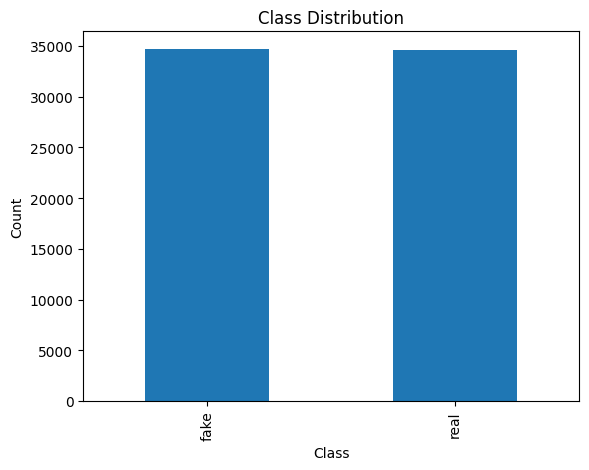

In [20]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Split-wise Distribution
Print the count of fake/real samples within each split (training, validation, testing).

In [21]:
print("Split Distribution")

print(
    df.groupby(["split","label"]).size()
)

Split Distribution
split       label
testing     fake      2370
            real      2264
training    fake     26927
            real     26941
validation  fake      5398
            real      5400
dtype: int64


## Split Distribution Table
Create a summary table showing counts for each split and label combination.

In [22]:
split_counts = (
    df.groupby(["split","label"])
      .size()
      .reset_index(name="count")
)

split_counts

,split,label,count
0,testing,fake,2370
1,testing,real,2264
2,training,fake,26927
3,training,real,26941
4,validation,fake,5398
5,validation,real,5400


In [23]:
print("Total Audio Files:")
print(len(df))

Total Audio Files:
69300


## Sample Audio File Path
Display the path of the first audio file in the dataset.

In [24]:
print("Sample Audio File")

print(df.iloc[0]["path"])

Sample Audio File
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/fake/file14215.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav


## Install Audio Processing Libraries
Install librosa and soundfile for audio loading and processing.

In [25]:
!pip install librosa soundfile -q

## Load and Visualize Waveform
Load a sample audio file and plot its waveform.

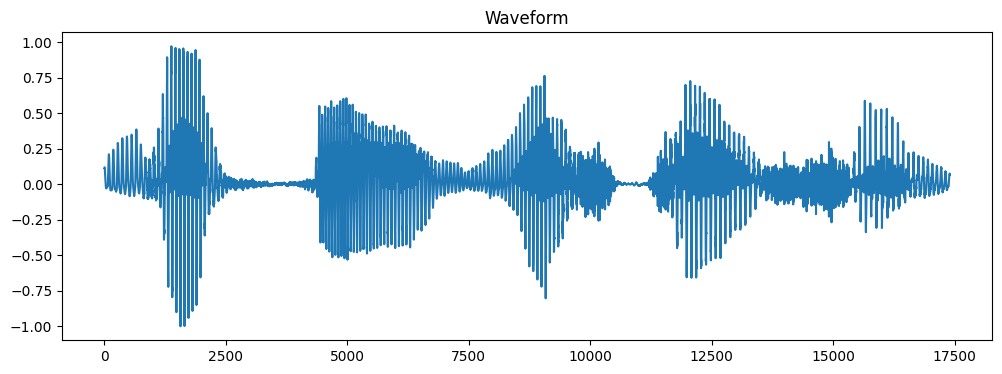

In [26]:
sample = df.iloc[0]["path"]

audio, sr = librosa.load(
    sample,
    sr=16000
)

plt.figure(figsize=(12,4))
plt.plot(audio)
plt.title("Waveform")
plt.show()

## Generate Mel Spectrogram
Convert the sample audio into a Mel spectrogram and visualize it.

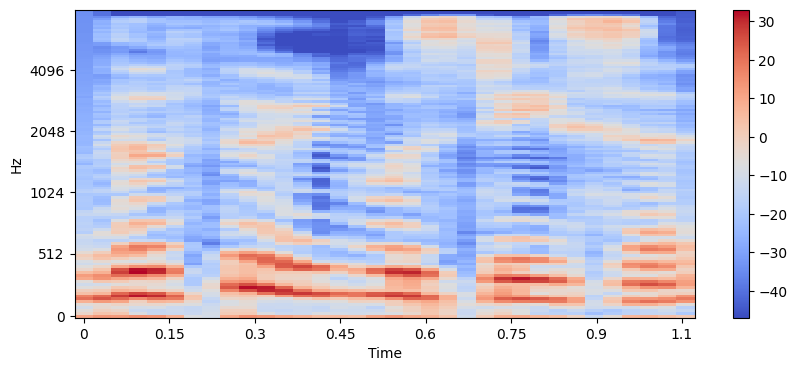

In [27]:
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()
plt.show()

## Define Mel Spectrogram Extraction Function
Create a function to load audio, generate a Mel spectrogram, convert it to decibel scale, and resize it to 128x128.

In [29]:
def extract_mel(path):

    audio, sr = librosa.load(
        path,
        sr=16000
    )

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel = librosa.power_to_db(mel)

    mel = tf.image.resize(
        mel[...,np.newaxis],
        (128,128)
    )

    return mel.numpy()

## Shuffle and Subsample Dataset
Shuffle the dataset and select a subset of 20,000 samples for training.

In [32]:
df = shuffle(df, random_state=42)

df_small = df[:20000]

print("Training Samples:", len(df_small))

Training Samples: 20000


## Extract Features for All Samples
Loop through the selected samples to extract Mel spectrograms (X) and corresponding labels (y).

In [33]:
from tqdm import tqdm
import numpy as np

X = []
y = []

for _, row in tqdm(
    df_small.iterrows(),
    total=len(df_small),
    desc="Extracting Mel Spectrograms"
):

    X.append(
        extract_mel(row["path"])
    )

    y.append(
        1 if row["label"] == "fake"
        else 0
    )

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y,
    dtype=np.int32
)

print("\nFeature Extraction Complete")
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print(
    "Approx Memory Usage:",
    round(X.nbytes / (1024**3), 2),
    "GB"
)

Extracting Mel Spectrograms:   0%|          | 0/20000 [00:00<?, ?it/s]I0000 00:00:1781513327.511781      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781513327.517688      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Extracting Mel Spectrograms:  34%|███▍      | 6807/20000 [04:03<05:57, 36.85it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
Extracting Mel Spectrograms:  52%|█████▏    | 10317/20000 [05:24<03:13, 50.08it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1891
  warnings.warn(
Extracting Mel S


Feature Extraction Complete
X Shape: (20000, 128, 128, 1)
y Shape: (20000,)
Approx Memory Usage: 1.22 GB


## Train-Test Split
Split the extracted features and labels into training and testing sets using stratified sampling.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (16000, 128, 128, 1)
Test Shape : (4000, 128, 128, 1)


## Convert to 3-Channel Images
Repeat the single-channel spectrogram across 3 channels to match the input format required by EfficientNet.

In [35]:
X_train = np.repeat(
    X_train,
    3,
    axis=-1
)

X_test = np.repeat(
    X_test,
    3,
    axis=-1
)

print("Updated Train Shape:", X_train.shape)
print("Updated Test Shape :", X_test.shape)

Updated Train Shape: (16000, 128, 128, 3)
Updated Test Shape : (4000, 128, 128, 3)


## Load Pretrained EfficientNetB0
Load EfficientNetB0 with ImageNet weights as the base feature extractor and freeze its layers.

In [36]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Build Classification Model
Add pooling, dense, and dropout layers on top of the base model for binary classification.

In [37]:
model = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )

])

## Compile Model
Compile the model with Adam optimizer, binary cross-entropy loss, and accuracy metric. Display model summary.

In [38]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Define Training Callbacks
Set up early stopping and learning rate reduction callbacks to improve training.

In [39]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )

]

## Train the Model
Train the model on the training data with validation split, using the defined callbacks.

In [40]:
history = model.fit(

    X_train,
    y_train,

    validation_split=0.1,

    epochs=15,

    batch_size=32,

    callbacks=callbacks

)

Epoch 1/15


I0000 00:00:1781514136.958455     328 service.cc:152] XLA service 0x7c78fc00edf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781514136.958512     328 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781514136.958519     328 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781514139.073269     328 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-15 09:02:26.034944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-15 09:02:26.169170: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-15 09:02:26.483712: E external/local_xl

450/450 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.8640 - loss: 0.3209 - val_accuracy: 0.8994 - val_loss: 0.2588 - learning_rate: 0.0010
Epoch 2/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8874 - loss: 0.2732 - val_accuracy: 0.9200 - val_loss: 0.2114 - learning_rate: 0.0010
Epoch 3/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8986 - loss: 0.2463 - val_accuracy: 0.9262 - val_loss: 0.1918 - learning_rate: 0.0010
Epoch 4/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9066 - loss: 0.2300 - val_accuracy: 0.9350 - val_loss: 0.1804 - learning_rate: 0.0010
Epoch 5/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9099 - loss: 0.2223 - val_accuracy: 0.9388 - val_loss: 0.1692 - learning_rate: 0.0010
Epoch 6/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9172 - loss: 0.2072 - val_accuracy: 0.9306 - val_loss: 0.1713 - learning_rate: 0.0010
Epoch 7/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9188 - loss: 0.2019 - val

## Generate Predictions
Predict probabilities on the test set and convert them into binary class labels.

In [41]:
pred_prob = model.predict(X_test)

pred = (
    pred_prob > 0.5
).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step


## Calcualte Accuracy

In [50]:
accuracy = accuracy_score(
    y_test,
    pred
)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.9545


## Calculate F1 Score

In [51]:
f1 = f1_score(
    y_test,
    pred
)

print("F1 Score:", round(f1, 4))

F1 Score: 0.955


## Generate Confusion Matrix

In [52]:
cm = confusion_matrix(
    y_test,
    pred
)

print(cm)

[[1887  123]
 [  59 1931]]


## Classification Report

In [53]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2010
           1       0.94      0.97      0.95      1990

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



## Calculate Equal Error Rate (EER)
Compute the EER, a common metric used in audio spoofing/deepfake detection.

In [49]:
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

fpr, tpr, thresholds = roc_curve(
    y_test,
    pred_prob
)

eer = brentq(
    lambda x: 1. - x - interp1d(fpr, tpr)(x),
    0.,
    1.
)

print(
    "EER:",
    round(eer * 100, 2),
    "%"
)

EER: 4.47 %


## Plot Confusion Matrix Heatmap
Visualize the confusion matrix using a heatmap for better interpretability.

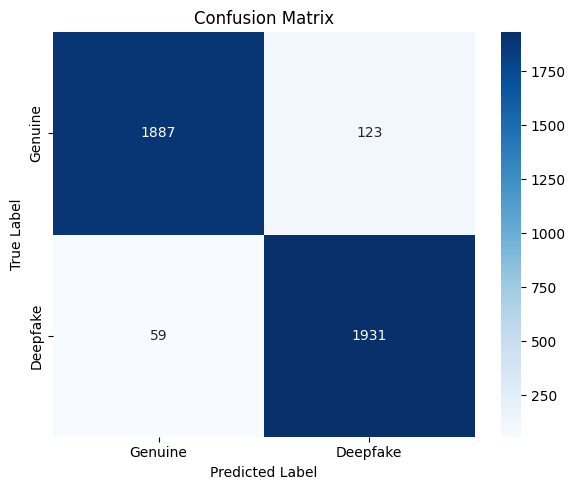

In [48]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Deepfake"],
    yticklabels=["Genuine", "Deepfake"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.show()

## Save the Trained Model
Save the trained model to disk in Keras format.

In [54]:
model.save(
    "deepfake_audio_model_20k.keras"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully
